# 🛒 E-Commerce Customer Segmentation & Product Recommendation

![Python](https://img.shields.io/badge/Python-3.10+-blue?logo=python)
![Pandas](https://img.shields.io/badge/Pandas-2.0+-lightgrey?logo=pandas)
![Sklearn](https://img.shields.io/badge/Scikit--Learn-1.3+-orange?logo=scikit-learn)
![Status](https://img.shields.io/badge/Status-Complete-brightgreen)

---

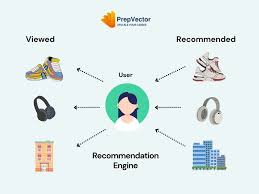

## 📌 Project Overview

This project analyzes a real-world **UK-based online retail dataset** to:

- **Explore & clean** transactional data
- **Build an RFM model** (Recency, Frequency, Monetary) to score customers
- **Segment customers** using K-Means clustering
- **Recommend products** using Cosine Similarity & segment-aware logic

---

## 📂 Dataset

| Field | Description |
|-------|-------------|
| **InvoiceNo** | Unique invoice number (prefix `C` = cancelled) |
| **StockCode** | Product code |
| **Description** | Product name |
| **Quantity** | Units purchased per transaction |
| **InvoiceDate** | Date and time of transaction |
| **UnitPrice** | Price per unit (GBP) |
| **CustomerID** | Unique customer identifier |
| **Country** | Customer's country |

> 📎 Source: [UCI Machine Learning Repository — Online Retail Dataset](https://archive.ics.uci.edu/ml/datasets/Online+Retail)

---

## 🗺️ Project Pipeline

```
Raw Data
   │
   ├── 1. Exploratory Data Analysis (EDA)
   ├── 2. Data Cleaning
   ├── 3. RFM Feature Engineering
   ├── 4. Customer Segmentation (K-Means)
   └── 5. Product Recommendation System
```

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 2. Exploratory Data Analysis (EDA)

In [2]:
# Load dataset with Latin-1 encoding (required for special characters)
data = pd.read_csv('data.csv', encoding='ISO-8859-1')
df = data.copy()

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
# Summary statistics for numerical columns
df.describe().round()

,Quantity,UnitPrice,CustomerID
count,541909.0,541909.0,406829.0
mean,10.0,5.0,15288.0
std,218.0,97.0,1714.0
min,-80995.0,-11062.0,12346.0
25%,1.0,1.0,13953.0
50%,3.0,2.0,15152.0
75%,10.0,4.0,16791.0
max,80995.0,38970.0,18287.0


In [5]:
# Summary statistics for categorical columns
df.describe(include='O')

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


In [6]:
# Check for missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
# Check for duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 5268


In [8]:
# Country distribution — dataset is UK-dominated (~91%)
print(f'Number of countries: {df.Country.nunique()}')
df.Country.value_counts(normalize=True).head(10)

Number of countries: 38


Country
United Kingdom    0.914320
Germany           0.017521
France            0.015790
EIRE              0.015124
Spain             0.004674
Netherlands       0.004375
Belgium           0.003818
Switzerland       0.003694
Portugal          0.002803
Australia         0.002323
Name: proportion, dtype: float64

In [9]:
# Identify numeric columns
num_cols = list(df.select_dtypes(include=['int64', 'float64']).columns)

# Show unique values for low-cardinality numeric columns
for col in num_cols:
    if df[col].nunique() <= 10:
        print(col)
        print(df[col].unique())
        print('*' * 50)

In [10]:
# Preview cancelled invoices — prefix 'C' indicates a cancellation
# These will be removed during cleaning
df[df.InvoiceNo.str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


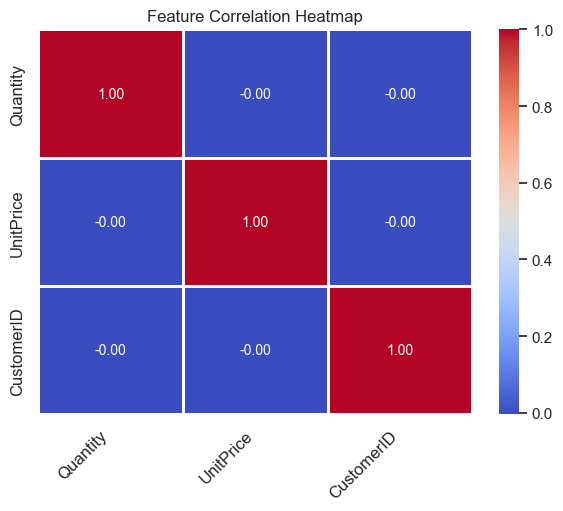

In [11]:
# Correlation heatmap between numerical features
plt.figure(figsize=(7, 5))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, linewidths=1, cmap='coolwarm',
            annot_kws={'size': 10}, fmt='.2f')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title('Feature Correlation Heatmap')
plt.show()

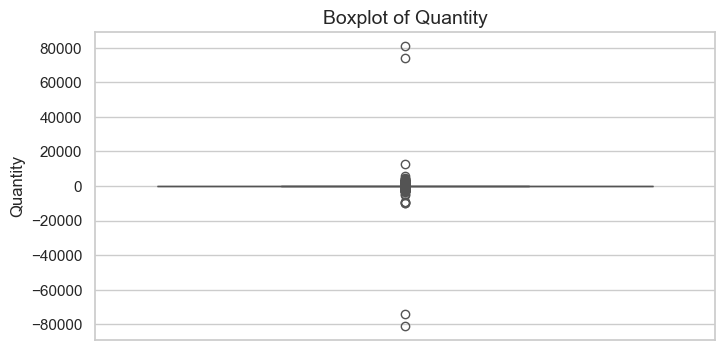

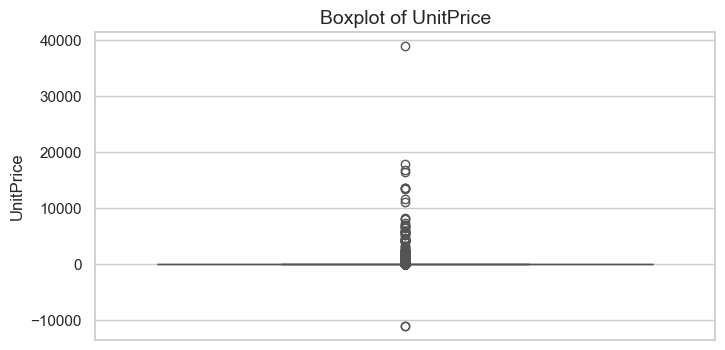

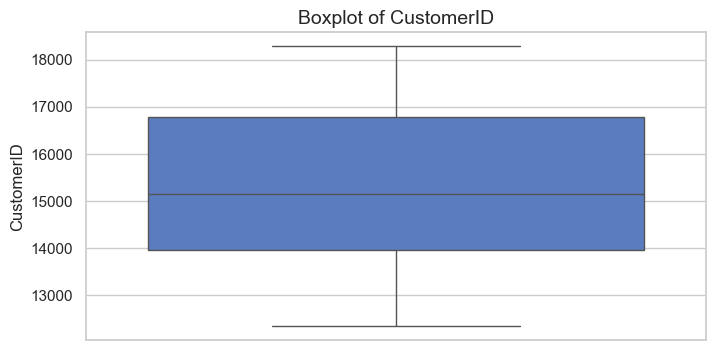

In [12]:
# Boxplots to detect outliers in each numerical column
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}', fontsize=14)
    plt.show()

In [13]:
# Quantify outliers using IQR method
def count_outliers(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((col < lower) | (col > upper)).sum()

outliers_df = (
    df[num_cols]
    .apply(count_outliers)
    .reset_index()
    .rename(columns={'index': 'Column', 0: 'Outliers_Count'})
    .sort_values(by='Outliers_Count', ascending=False)
    .reset_index(drop=True)
)
outliers_df['percentage %'] = [round((c / len(df)) * 100, 2) for c in outliers_df['Outliers_Count']]
outliers_df

,Column,Outliers_Count,percentage %
0,Quantity,58619,10.82
1,UnitPrice,39627,7.31
2,CustomerID,0,0.00


## 3. Data Cleaning

Steps applied:
- Standardize column names
- Fill missing `description` with mode
- Drop rows with missing `customerid` (can't be imputed — each ID is unique)
- Parse `invoicedate` to datetime
- Remove cancelled invoices (prefix `C`)
- Remove zero/negative quantities and prices
- Clip outliers at 99th percentile (preserve data, reduce skew)
- Create `total_price` feature
- Drop duplicates

In [14]:
# Identify categorical columns before renaming
cat_cols = [col for col in df.columns if col not in num_cols]
print('Categorical columns:', cat_cols)

Categorical columns: ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']


In [15]:
# Standardize column names: lowercase, underscores, no extra spaces
df.columns = df.columns.str.lower().str.replace(' ', '_').str.strip()
print(df.columns.tolist())

['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country']


In [16]:
df.isnull().sum()

invoiceno           0
stockcode           0
description      1454
quantity            0
invoicedate         0
unitprice           0
customerid     135080
country             0
dtype: int64

In [17]:
# Fill missing description with the most frequent value
df['description'] = df['description'].fillna(df['description'].mode()[0])

# Drop rows with missing CustomerID — IDs are unique and cannot be imputed
df = df.dropna(subset=['customerid'])

# Parse invoice date early to enable date-based features
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [18]:
# Remove cancelled transactions (InvoiceNo starting with 'C')
df = df[~df['invoiceno'].str.startswith('C')]
print(f'Shape after removing cancellations: {df.shape}')

Shape after removing cancellations: (397924, 8)


In [19]:
# Check extreme quantity values
print(f'Rows with quantity >= 50,000: {df[df["quantity"] >= 50000].shape[0]}')

# Keep only valid transactions
df = df[df['quantity'] > 0]
df = df[df['unitprice'] > 0]

Rows with quantity >= 50,000: 2


In [20]:
# Clip quantity at 99th percentile to reduce extreme outlier effect
q_high = df['quantity'].quantile(0.99)
df['quantity'] = df['quantity'].clip(upper=q_high)

# Clip unit price at 99th percentile
unit_high = df['unitprice'].quantile(0.99)
df['unitprice'] = df['unitprice'].clip(upper=unit_high)

print(f'Quantity clipped at: {q_high}')
print(f'Unit price clipped at: {unit_high}')

Quantity clipped at: 120.0
Unit price clipped at: 14.95


In [21]:
# Create total_price feature: revenue per line item
df['total_price'] = df['quantity'] * df['unitprice']

# Drop duplicate rows
df.drop_duplicates(inplace=True)

print(f'Final dataset shape: {df.shape}')
df.describe().round(2)

Final dataset shape: (392677, 9)


,quantity,invoicedate,unitprice,customerid,total_price
count,392677.00,392677,392677.00,392677.00,392677.00
mean,11.02,2011-07-10 19:14:00.635789824,2.83,15287.89,19.46
min,1.00,2010-12-01 08:26:00,0.00,12346.00,0.00
25%,2.00,2011-04-07 11:12:00,1.25,13955.00,4.95
50%,6.00,2011-07-31 12:02:00,1.95,15150.00,12.39
75%,12.00,2011-10-20 12:53:00,3.75,16791.00,19.80
max,120.00,2011-12-09 12:50:00,14.95,18287.00,1794.00
std,18.15,NaN,2.79,1713.51,37.49


In [22]:
# Re-check outliers after cleaning
num_cols = list(df.select_dtypes(include=['int64', 'float64']).columns)

outliers_df = (
    df[num_cols]
    .apply(count_outliers)
    .reset_index()
    .rename(columns={'index': 'Column', 0: 'Outliers_Count'})
    .sort_values(by='Outliers_Count', ascending=False)
    .reset_index(drop=True)
)
outliers_df['percentage %'] = [round((c / len(df)) * 100, 2) for c in outliers_df['Outliers_Count']]
outliers_df

,Column,Outliers_Count,percentage %
0,unitprice,34102,8.68
1,total_price,30388,7.74
2,quantity,25611,6.52
3,customerid,0,0.00


## 4. RFM Feature Engineering

**RFM** is a proven framework for customer behavior analysis:

| Metric | Definition | Better when... |
|--------|------------|----------------|
| **Recency** | Days since last purchase | Lower |
| **Frequency** | Number of unique invoices | Higher |
| **Monetary** | Total amount spent | Higher |

Each metric is then scored 1–5 using quantiles, and combined into an **RFM Score** to rank customers objectively.

In [23]:
# Snapshot date = 1 day after the last transaction (reference point for Recency)
snapshot_date = df['invoicedate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customerid').agg({
    'invoicedate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'invoiceno':   'nunique',                                  # Frequency
    'total_price': 'sum'                                       # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
customerid,,,
12346.0,326,1,124.80
12347.0,2,7,4185.20
12348.0,75,4,1530.03
12349.0,19,1,1443.50
12350.0,310,1,309.35


In [24]:
rfm.describe().round()

,Recency,Frequency,Monetary
count,4338.0,4338.0,4338.0
mean,93.0,4.0,1761.0
std,100.0,8.0,6319.0
min,1.0,1.0,4.0
25%,18.0,1.0,295.0
50%,51.0,2.0,647.0
75%,142.0,5.0,1581.0
max,374.0,209.0,225195.0


In [25]:
# Score each RFM metric on a 1–5 scale using quantiles
# Note: Recency is reversed — lower recency = more recent = better score
# rank(method='first') handles ties to ensure equal bin sizes
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  5, labels=[1,2,3,4,5]).astype(int)

# Combined RFM Score (range: 3 to 15)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

rfm.describe().round()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
count,4338.0,4338.0,4338.0,4338.0,4338.0,4338.0,4338.0
mean,93.0,4.0,1761.0,3.0,3.0,3.0,9.0
std,100.0,8.0,6319.0,1.0,1.0,1.0,4.0
min,1.0,1.0,4.0,1.0,1.0,1.0,3.0
25%,18.0,1.0,295.0,2.0,2.0,2.0,6.0
50%,51.0,2.0,647.0,3.0,3.0,3.0,9.0
75%,142.0,5.0,1581.0,4.0,4.0,4.0,12.0
max,374.0,209.0,225195.0,5.0,5.0,5.0,15.0


In [26]:
# Apply log1p transform to reduce skewness in Monetary and Frequency
# Done AFTER scoring so scores are based on original values
rfm['Monetary']  = np.log1p(rfm['Monetary'])
rfm['Frequency'] = np.log1p(rfm['Frequency'])

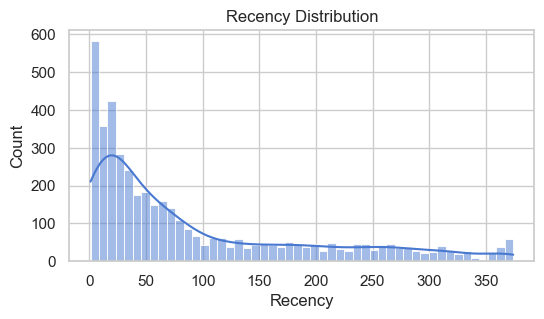

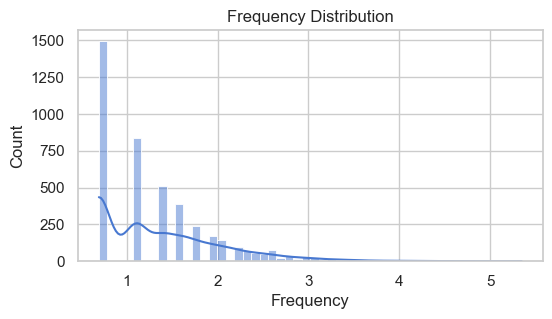

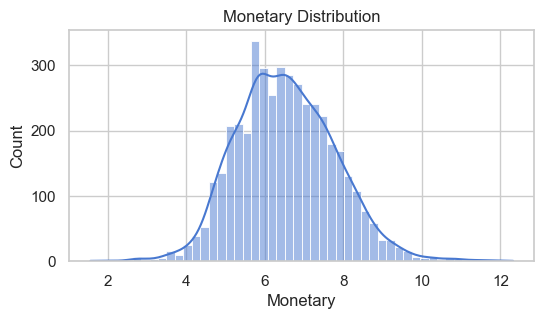

In [27]:
# Distribution of RFM features after log transform
for col in ['Recency', 'Frequency', 'Monetary']:
    plt.figure(figsize=(6, 3))
    sns.histplot(rfm[col], bins=50, kde=True)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.show()

## 5. Customer Segmentation (K-Means Clustering)

Steps:
1. Scale RFM features using `StandardScaler`
2. Use the **Elbow Method** to find the optimal number of clusters
3. Fit K-Means and evaluate with **Silhouette Score**
4. Label clusters as human-readable segments

In [28]:
# Scale only the core RFM features (not scores) before clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

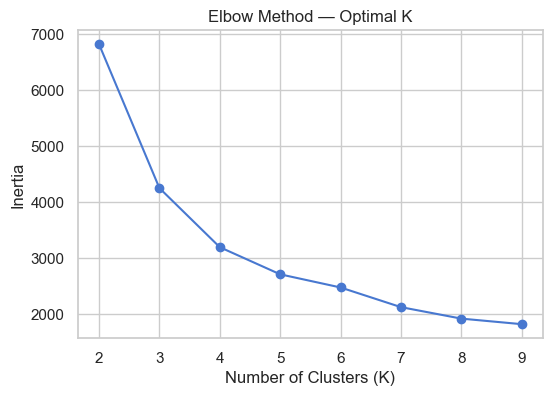

In [29]:
# Elbow Method: find optimal K by plotting inertia vs number of clusters
inertia = []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K')
plt.show()

In [30]:
# Train final K-Means model with K=4 (selected from elbow plot)
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [31]:
# Evaluate clustering quality
# Silhouette Score: ranges from -1 (bad) to 1 (perfect). Above 0.25 is acceptable.
score = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.383


In [32]:
# Mean RFM values per cluster — helps understand cluster profiles
rfm.groupby('Cluster').mean().round(2)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Cluster,,,,,,,
0,58.68,0.90,5.74,3.16,2.07,2.02,7.25
1,44.69,1.63,7.21,3.59,3.94,3.99,11.52
2,259.46,0.83,5.57,1.11,1.85,1.85,4.81
3,17.63,2.68,8.58,4.46,4.99,4.96,14.41


In [33]:
# Label customers based on their RFM Score (data-driven, not hardcoded)
# RFM Score ranges from 3 (worst) to 15 (best)
def label_cluster(row):
    if row['RFM_Score'] >= 13:
        return 'VIP'      # High score across all 3 metrics
    elif row['RFM_Score'] >= 9:
        return 'Loyal'    # Above average overall
    elif row['R_Score'] <= 2:
        return 'Lost'     # Haven't purchased recently
    else:
        return 'Regular'  # Average customers

rfm['Segment'] = rfm.apply(label_cluster, axis=1)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,Segment
customerid,,,,,,,,,
12346.0,326,0.693147,4.834693,1,1,1,3,2,Lost
12347.0,2,2.079442,8.339549,5,5,5,15,3,VIP
12348.0,75,1.609438,7.333696,2,4,4,10,1,Loyal
12349.0,19,0.693147,7.275519,4,1,4,9,0,Loyal
12350.0,310,0.693147,5.737701,1,1,2,4,2,Lost


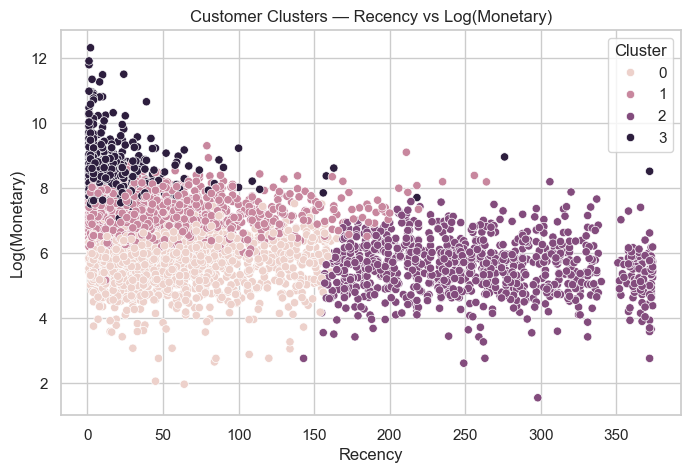

In [34]:
# Scatter plot: Recency vs Monetary colored by cluster
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='Recency',
    y='Monetary',   # Already log-transformed
    hue='Cluster',
    data=rfm
)
plt.title('Customer Clusters — Recency vs Log(Monetary)')
plt.ylabel('Log(Monetary)')
plt.show()

In [35]:
# Segment summary: average RFM metrics and customer count per segment
rfm.groupby('Segment').agg({
    'Recency':   'mean',
    'Frequency': 'mean',
    'Monetary':  'mean'
}).round(2).assign(Count=rfm.groupby('Segment').size())

,Recency,Frequency,Monetary,Count
Segment,,,,
Lost,207.64,0.86,5.67,1422
Loyal,49.72,1.44,6.84,1342
Regular,40.35,0.79,5.50,637
VIP,14.66,2.33,8.12,937


## 6. Product Recommendation System

Two recommendation approaches:

| Approach | Method | Use Case |
|----------|--------|----------|
| **Item-based** | Cosine Similarity on basket matrix | "Customers who bought X also bought..." |
| **Segment-based** | Top products by customer segment | Personalized recommendations per tier |

In [36]:
# Build binary basket matrix for UK transactions only
# Rows = invoices, Columns = products, Values = 1 (bought) or 0 (not bought)
basket = (
    df[df['country'] == 'United Kingdom']
    .groupby(['invoiceno', 'description'])['quantity']
    .sum()
    .unstack()
    .fillna(0)
)

# Binarize: 1 if product was purchased, 0 otherwise
basket = basket.map(lambda x: 1 if x > 0 else 0)

print(f'Basket matrix shape: {basket.shape}')
basket.head()

Basket matrix shape: (16646, 3844)


description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TOADSTOOL BEDSIDE LIGHT,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
invoiceno,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Compute cosine similarity between all products
# Higher similarity = products are frequently bought together
similarity = cosine_similarity(basket.T)
similarity_df = pd.DataFrame(similarity, index=basket.columns, columns=basket.columns)

In [ ]:
def recommend(product, n=5):
    """
    Return top-N similar products based on cosine similarity.
    
    Parameters:
        product (str): Product name (must match basket column exactly)
        n (int): Number of recommendations to return
    
    Returns:
        pd.Series: Top-N similar products with similarity scores
    """
    return similarity_df[product].sort_values(ascending=False)[1:n+1]

# Example usage
recommend('WHITE HANGING HEART T-LIGHT HOLDER')

In [ ]:
def recommend_for_segment(segment, n=5):
    """
    Return top-N products most purchased by customers in a given segment.
    Uses top 20 customers by combined Frequency × Monetary score.
    
    Parameters:
        segment (str): One of 'VIP', 'Loyal', 'Regular', 'Lost'
        n (int): Number of products to return
    
    Returns:
        pd.Series: Top-N products with total quantity sold
    """
    top = rfm[rfm['Segment'] == segment].copy()
    top['score'] = top['Frequency'] * top['Monetary']
    top_customers = top.nlargest(20, 'score').index

    top_products = (
        df[df['customerid'].isin(top_customers)]
        .groupby('description')['quantity']
        .sum()
        .sort_values(ascending=False)
        .head(n)
    )
    return top_products

# Example: Top products for VIP customers
print('Top products for VIP customers:')
print(recommend_for_segment(segment='VIP', n=5))

## 7. ✅ Summary

| Step | Output |
|------|--------|
| EDA | Identified missing values, outliers, and cancelled orders |
| Cleaning | Removed ~25% of rows (nulls, cancellations, invalid prices) |
| RFM | Scored each customer 3–15 across Recency, Frequency, Monetary |
| Clustering | 4 K-Means clusters, Silhouette Score ≈ 0.38 |
| Segments | VIP / Loyal / Regular / Lost |
| Recommendations | Item-based (cosine) + Segment-aware top products |
